In [1]:
"""
AI Project Failure Analysis — EDA + Statistical Tests + Charts
"""
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import os
import warnings
warnings.filterwarnings('ignore')

os.makedirs('outputs', exist_ok=True)

In [3]:

# ─────────────────────────────────────────────────────────────
# 1. LOAD DATA
# ─────────────────────────────────────────────────────────────
df = pd.read_csv('ai_projects.csv')
print(f"Dataset: {df.shape[0]} AI projects | {df['industry'].nunique()} industries\n")

# ─────────────────────────────────────────────────────────────
# 2. EXPLORATORY DATA ANALYSIS
# ─────────────────────────────────────────────────────────────
print("=== Outcome Distribution ===")
outcome_counts = df['outcome'].value_counts()
failure_rate   = df['outcome'].isin(['Failed','Partial Failure']).mean() * 100
print(outcome_counts)
print(f"\nOverall Failure / Partial-Failure Rate: {failure_rate:.1f}%")

score_cols = ['data_readiness_score','leadership_support_score',
              'talent_score','change_mgmt_score']
print("\n=== Average Scores by Outcome ===")
print(df.groupby('outcome')[score_cols].mean().round(2))

print("\n=== Top 5 Primary Failure Reasons ===")
print(df[df['outcome']=='Failed']['primary_failure_reason'].value_counts().head(5))

Dataset: 300 AI projects | 8 industries

=== Outcome Distribution ===
outcome
Failed               104
Partial Failure       83
Succeeded             69
Ongoing (At Risk)     44
Name: count, dtype: int64

Overall Failure / Partial-Failure Rate: 62.3%

=== Average Scores by Outcome ===
                   data_readiness_score  leadership_support_score  \
outcome                                                             
Failed                             4.26                      3.74   
Ongoing (At Risk)                  3.77                      3.75   
Partial Failure                    3.96                      3.64   
Succeeded                          6.93                      7.12   

                   talent_score  change_mgmt_score  
outcome                                             
Failed                     5.22               3.62  
Ongoing (At Risk)          5.36               3.73  
Partial Failure            5.12               3.35  
Succeeded                  5.36   

In [4]:

# ─────────────────────────────────────────────────────────────
# 3. STATISTICAL TESTS
# ─────────────────────────────────────────────────────────────
print("\n=== T-test: Data Readiness (Succeeded vs Failed) ===")
succ  = df[df['outcome']=='Succeeded']['data_readiness_score']
fail  = df[df['outcome']=='Failed']['data_readiness_score']
t, p  = stats.ttest_ind(succ, fail)
print(f"t = {t:.3f},  p = {p:.4f}  →  {'Significant ✓' if p < 0.05 else 'Not significant'}")

print("\n=== Chi-Square: Data Governance vs Success ===")
ct = pd.crosstab(df['has_data_governance'], df['outcome'] == 'Succeeded')
chi2, p_chi, dof, _ = stats.chi2_contingency(ct)
print(f"χ²= {chi2:.3f},  p = {p_chi:.4f}  →  {'Significant ✓' if p_chi < 0.05 else 'Not significant'}")

print("\n=== Correlation with Success (binary) ===")
df_c = df.copy()
df_c['success_binary'] = (df_c['outcome'] == 'Succeeded').astype(int)
corr = df_c[score_cols + ['success_binary']].corr()['success_binary'].drop('success_binary')
print(corr.sort_values(ascending=False).round(3))


=== T-test: Data Readiness (Succeeded vs Failed) ===
t = 14.193,  p = 0.0000  →  Significant ✓

=== Chi-Square: Data Governance vs Success ===
χ²= 0.374,  p = 0.5406  →  Not significant

=== Correlation with Success (binary) ===
leadership_support_score    0.714
data_readiness_score        0.668
change_mgmt_score           0.666
talent_score                0.031
Name: success_binary, dtype: float64


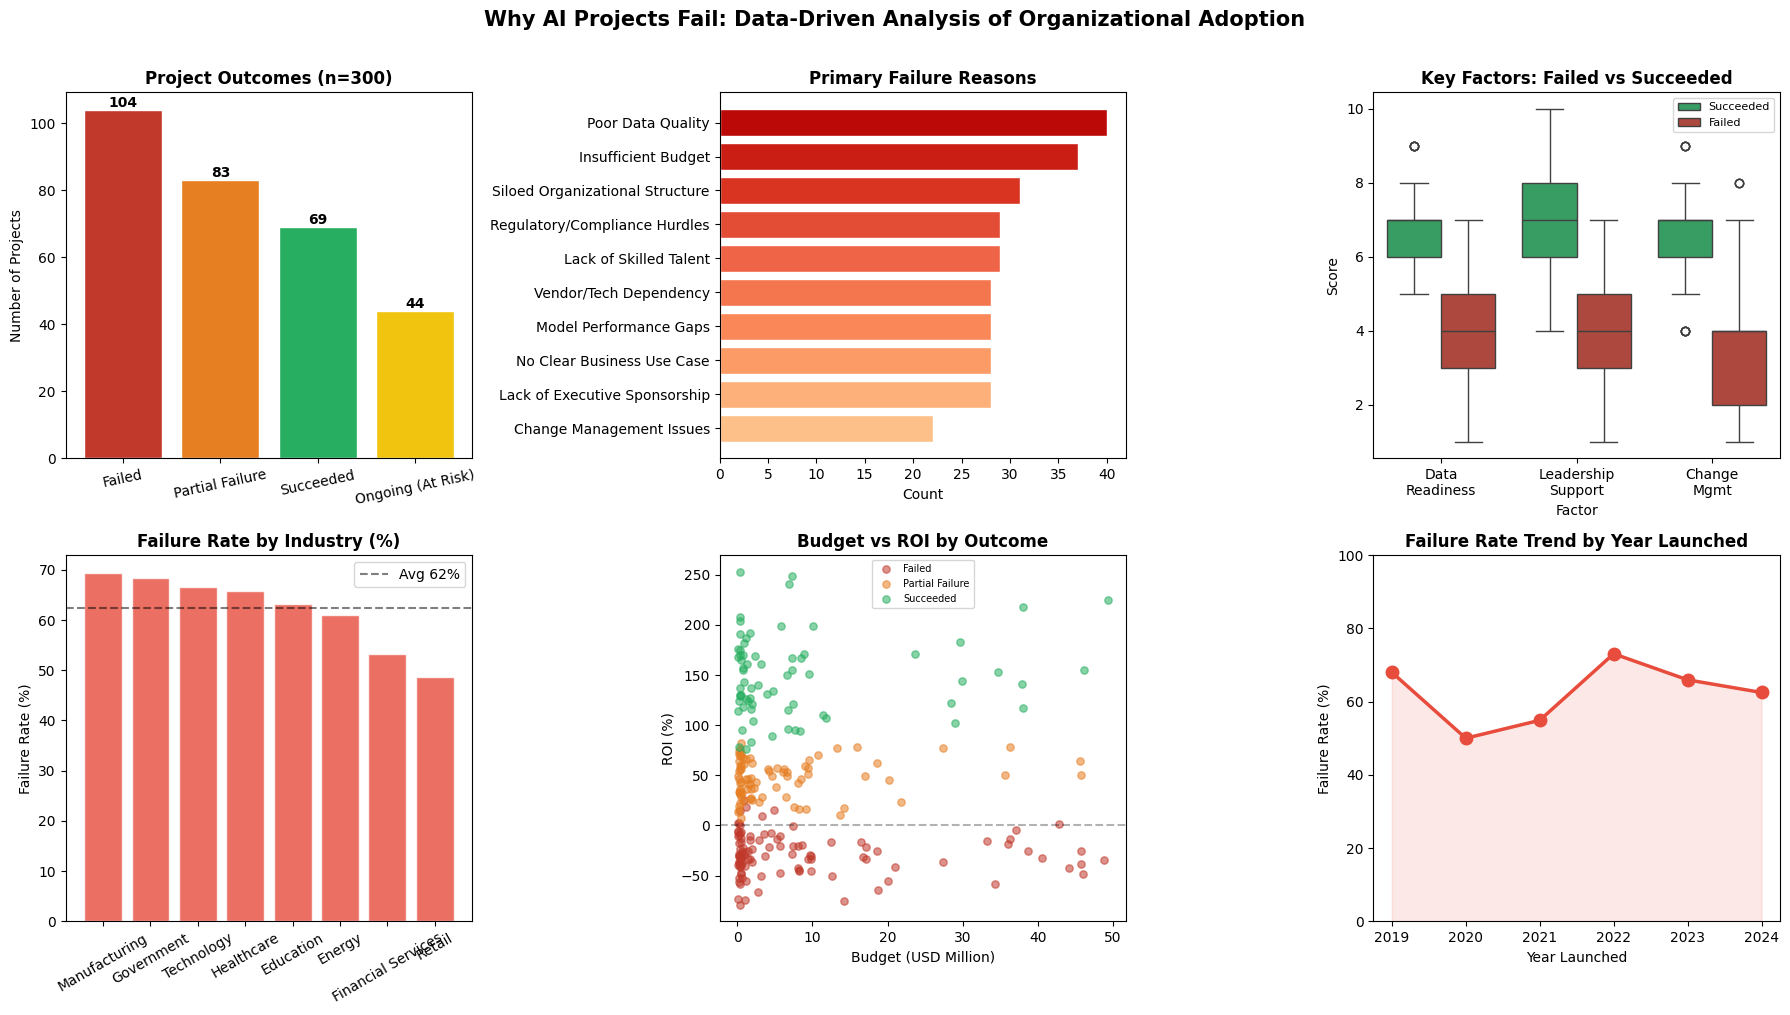


Chart saved → outputs/ai_failure_analysis.png


In [6]:
# ─────────────────────────────────────────────────────────────
# 4. VISUALIZATIONS  (6-panel figure)
# ─────────────────────────────────────────────────────────────
palette = {
    'Failed'           : '#c0392b',
    'Partial Failure'  : '#e67e22',
    'Ongoing (At Risk)': '#f1c40f',
    'Succeeded'        : '#27ae60'
}

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle("Why AI Projects Fail: Data-Driven Analysis of Organizational Adoption",
             fontsize=15, fontweight='bold', y=1.01)

# ── Panel 1: Outcome distribution ──────────────────────────
ax = axes[0, 0]
bars = ax.bar(outcome_counts.index, outcome_counts.values,
              color=[palette[x] for x in outcome_counts.index], edgecolor='white')
ax.set_title('Project Outcomes (n=300)', fontweight='bold')
ax.set_ylabel('Number of Projects')
for bar, val in zip(bars, outcome_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.8,
            str(val), ha='center', fontsize=10, fontweight='bold')
ax.tick_params(axis='x', rotation=12)

# ── Panel 2: Top failure reasons ───────────────────────────
ax = axes[0, 1]
rc = df['primary_failure_reason'].value_counts()
colors = plt.cm.OrRd(np.linspace(0.35, 0.85, len(rc)))[::-1]
ax.barh(rc.index, rc.values, color=colors, edgecolor='white')
ax.set_title('Primary Failure Reasons', fontweight='bold')
ax.set_xlabel('Count')
ax.invert_yaxis()

# ── Panel 3: Key factor boxplots (Failed vs Succeeded) ─────
ax = axes[0, 2]
df_melt = df[df['outcome'].isin(['Failed','Succeeded'])].melt(
    id_vars='outcome',
    value_vars=['data_readiness_score','leadership_support_score','change_mgmt_score'],
    var_name='Factor', value_name='Score'
)
labels = {
    'data_readiness_score'    : 'Data\nReadiness',
    'leadership_support_score': 'Leadership\nSupport',
    'change_mgmt_score'       : 'Change\nMgmt'
}
df_melt['Factor'] = df_melt['Factor'].map(labels)
sns.boxplot(data=df_melt, x='Factor', y='Score', hue='outcome',
            ax=ax, palette={'Failed':'#c0392b','Succeeded':'#27ae60'})
ax.set_title('Key Factors: Failed vs Succeeded', fontweight='bold')
ax.legend(title='', fontsize=8)

# ── Panel 4: Industry failure rates ────────────────────────
ax = axes[1, 0]
ind_fail = (df.groupby('industry')
              .apply(lambda x: x['outcome'].isin(['Failed','Partial Failure']).mean()*100)
              .sort_values(ascending=False))
ax.bar(ind_fail.index, ind_fail.values, color='#e74c3c', alpha=0.8, edgecolor='white')
ax.axhline(failure_rate, color='black', linestyle='--', alpha=0.5,
           label=f'Avg {failure_rate:.0f}%')
ax.set_title('Failure Rate by Industry (%)', fontweight='bold')
ax.set_ylabel('Failure Rate (%)')
ax.tick_params(axis='x', rotation=30)
ax.legend()

# ── Panel 5: Budget vs ROI scatter ─────────────────────────
ax = axes[1, 1]
df_roi = df.dropna(subset=['roi_pct'])
for out, grp in df_roi.groupby('outcome'):
    ax.scatter(grp['budget_usd_m'], grp['roi_pct'],
               alpha=0.55, label=out, color=palette.get(out,'gray'), s=28)
ax.axhline(0, color='black', linestyle='--', alpha=0.3)
ax.set_xlabel('Budget (USD Million)')
ax.set_ylabel('ROI (%)')
ax.set_title('Budget vs ROI by Outcome', fontweight='bold')
ax.legend(fontsize=7)

# ── Panel 6: Failure rate year trend ───────────────────────
ax = axes[1, 2]
yr = (df.groupby('year_launched')
        .apply(lambda x: x['outcome'].isin(['Failed','Partial Failure']).mean()*100))
ax.plot(yr.index, yr.values, marker='o', color='#e74c3c', linewidth=2.5, markersize=9)
ax.fill_between(yr.index, yr.values, alpha=0.12, color='#e74c3c')
ax.set_title('Failure Rate Trend by Year Launched', fontweight='bold')
ax.set_ylabel('Failure Rate (%)')
ax.set_xlabel('Year Launched')
ax.set_ylim(0, 100)

plt.tight_layout()
plt.savefig('outputs/ai_failure_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("\nChart saved → outputs/ai_failure_analysis.png")

In [7]:
# ─────────────────────────────────────────────────────────────
# 5. GOVERNANCE & TEAM IMPACT TABLES
# ─────────────────────────────────────────────────────────────
print("\n=== Governance Impact on Success Rate ===")
print(pd.crosstab(df['has_data_governance'], df['outcome'],
                  normalize='index').round(3).mul(100))

print("\n=== Dedicated AI Team Impact on Success Rate ===")
print(pd.crosstab(df['has_dedicated_ai_team'], df['outcome'],
                  normalize='index').round(3).mul(100))


=== Governance Impact on Success Rate ===
outcome              Failed  Ongoing (At Risk)  Partial Failure  Succeeded
has_data_governance                                                       
False                  47.0                8.6             23.2       21.2
True                   22.1               20.8             32.2       24.8

=== Dedicated AI Team Impact on Success Rate ===
outcome                Failed  Ongoing (At Risk)  Partial Failure  Succeeded
has_dedicated_ai_team                                                       
False                    38.8               13.6             34.7       12.9
True                     30.7               15.7             20.9       32.7
